# Multi-class and Multi-Label Classification Using Support Vector Machines

Import packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, hamming_loss, calinski_harabasz_score, silhouette_score
from sklearn.model_selection import KFold, StratifiedKFold, GridSearchCV
from sklearn.svm import SVC, LinearSVC
from sklearn.cluster import KMeans
from imblearn.over_sampling import SMOTE

### (a) Download the Anuran Calls (MFCCs) Data Set

In [2]:
mfcc_df = pd.read_csv('../data/Anuran Calls (MFCCs)/Frogs_MFCCs.csv')

labels = ['Family', 'Genus', 'Species']
mfcc_df_encoded = mfcc_df.copy()
for label in labels:
    encoder = LabelEncoder()
    mfcc_df_encoded[f'{label}_Encoded'] = encoder.fit_transform(mfcc_df[label])

train_df = mfcc_df_encoded.sample(frac=0.7, random_state=24)
test_df = mfcc_df_encoded.drop(train_df.index)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print('Original Shape:', mfcc_df.shape)
print('Training Shape:', train_df.shape)
print('Test Shape:', test_df.shape)

Original Shape: (7195, 26)
Training Shape: (5036, 29)
Test Shape: (2159, 29)


In [3]:
X_train = train_df.iloc[:, :-7]
y_train = train_df.iloc[:, -3:]
X_test = test_df.iloc[:, :-7]
y_test = test_df.iloc[:, -3:]

y_train.value_counts()

Family_Encoded  Genus_Encoded  Species_Encoded
3               0              1                  2440
2               3              5                   778
3               0              0                   472
1               1              2                   393
2               3              4                   318
                2              3                   220
3               4              6                   184
2               7              9                   107
                5              7                    75
0               6              8                    49
Name: count, dtype: int64

We can see that we are working with an imbalanced dataset and thus techniques such as stratified cross validation and SMOTE might be useful. 

### (b) Train a classifier for each label

#### (i) Research

Exact Match - This measures the percentage of instances where the predicted labels exactly match the true labels. In a multi-label classification problem, this is essentially the same of measuring the accuracy of our classifier, which is just the proportion of correct predictions. 

Hamming Score/Loss - This metric is less strict than exact match because it accounts for partial correctness, which is especially relevant in a multi-label classification problem such as this one. It does this by considering each label prediction independently and calculating the average number of label misclassifications per instance. Think of this as giving 'partial credit' for each unique label.  

#### (ii) Train a SVM for each of the labels

In [4]:
def paramater_search(X_train, X_test, y_train, y_test, label, C_list, gamma_list):
    
    stratified_kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=24)
    results = {'C':[], 'Gamma':[], '# of Times Picked': [], 'Mean Accuracy':[]}
    accuracy_dict = {(C, gamma): [] for C in C_list for gamma in gamma_list}
    num_picks_dict = {(C, gamma): 0 for C in C_list for gamma in gamma_list}
    y_label = y_train[f'{label}_Encoded']
    
    for train_index, val_index in stratified_kfold.split(X_train, y_label):
        X_subtrain, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
        y_subtrain, y_val = y_label.iloc[train_index], y_label.iloc[val_index]

        param_grid = {'C': C_list, 'gamma': gamma_list}
        svm_classifier = SVC(kernel='rbf', decision_function_shape='ovr')
        grid_search = GridSearchCV(estimator=svm_classifier, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_subtrain, y_subtrain)
        best_C = grid_search.best_params_['C']
        best_gamma = grid_search.best_params_['gamma']
        
        best_svm = SVC(kernel='rbf', decision_function_shape='ovr', C=best_C, gamma=best_gamma)
        best_svm.fit(X_subtrain, y_subtrain)
        y_pred = best_svm.predict(X_val)
        accuracy = accuracy_score(y_val, y_pred)
        
        accuracy_dict[(best_C, best_gamma)].append(accuracy)
        num_picks_dict[(best_C, best_gamma)] += 1
        
    for (C_value, gamma_value), accuracies in accuracy_dict.items():
        if accuracies:            
            mean_accuracy = sum(accuracies) / len(accuracies)
            results['C'].append(C_value)
            results['Gamma'].append(gamma_value)
            results['Mean Accuracy'].append(mean_accuracy)
            num_picks = num_picks_dict[(C_value, gamma_value)]
            results['# of Times Picked'].append(num_picks)
    
    results_df = pd.DataFrame(results)
    print(f'Cross Validation Results for {label}')
    return results_df

In [5]:
X_train = train_df.iloc[:, :-7]
y_train = train_df.iloc[:, -3:]
X_test = test_df.iloc[:, :-7]
y_test = test_df.iloc[:, -3:]

C_list = [0.01, 0.1, 1, 10, 100]
gamma_list = [0.01, 0.1, 1, 10, 100]

paramater_search(X_train, X_test, y_train, y_test, 'Family', C_list, gamma_list)

Cross Validation Results for Family


,C,Gamma,# of Times Picked,Mean Accuracy
0,10,1,1,0.994036
1,100,1,9,0.990295


In [6]:
optimal_family_svm = SVC(kernel='rbf', decision_function_shape='ovr', C=100, gamma=1)
optimal_family_svm.fit(X_train, y_train['Family_Encoded'])
y_pred_family = optimal_family_svm.predict(X_test)
family_accuracy = accuracy_score(y_test['Family_Encoded'], y_pred_family)
print('Family Label SVM Test Accuracy:', family_accuracy)

Family Label SVM Test Accuracy: 0.9907364520611394


In [7]:
paramater_search(X_train, X_test, y_train, y_test, 'Genus', C_list, gamma_list)

Cross Validation Results for Genus


,C,Gamma,# of Times Picked,Mean Accuracy
0,10,1,5,0.990866
1,100,1,5,0.990472


In [8]:
optimal_genus_svm = SVC(kernel='rbf', decision_function_shape='ovr', C=10, gamma=1)
optimal_genus_svm.fit(X_train, y_train['Genus_Encoded'])
y_pred_genus = optimal_genus_svm.predict(X_test)
genus_accuracy = accuracy_score(y_test['Genus_Encoded'], y_pred_genus)
print('Genus Label SVM Test Accuracy:', genus_accuracy)

Genus Label SVM Test Accuracy: 0.9884205650764243


In [9]:
paramater_search(X_train, X_test, y_train, y_test, 'Species', C_list, gamma_list)

Cross Validation Results for Species


,C,Gamma,# of Times Picked,Mean Accuracy
0,10,1,3,0.994041
1,100,1,7,0.988091


In [10]:
optimal_species_svm = SVC(kernel='rbf', decision_function_shape='ovr', C=100, gamma=1)
optimal_species_svm.fit(X_train, y_train['Species_Encoded'])
y_pred_species = optimal_species_svm.predict(X_test)
species_accuracy = accuracy_score(y_test['Species_Encoded'], y_pred_species)
print('Species Label SVM Test Accuracy:', species_accuracy)

Species Label SVM Test Accuracy: 0.9870310328855951


In [11]:
multi_label_pred = np.array([y_pred_family, y_pred_genus, y_pred_species]).T
exact_match_score = np.mean(np.all(y_test == multi_label_pred, axis=1))
hamming_score = np.mean(y_test == multi_label_pred)

print('Exact Match Score for SVM w/ Gaussian Kernel:', exact_match_score)
print('Hamming Score for SVM w/ Gaussian Kernel:', hamming_score)

Exact Match Score for SVM w/ Gaussian Kernel: 0.9833256137100509
Hamming Score for SVM w/ Gaussian Kernel: 0.9887293500077197


#### (iii) Repeat 1(b)ii with L1-penalized SVMs

In [12]:
def paramater_search_l1(X_train, X_test, y_train, y_test, label, C_list):
    
    stratified_kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=24)
    results = {'C':[], '# of Times Picked': [], 'Mean Accuracy':[]}
    accuracy_dict = {C: [] for C in C_list}
    num_picks_dict = {C: 0 for C in C_list}
    y_label = y_train[f'{label}_Encoded']
    
    for train_index, val_index in stratified_kfold.split(X_train, y_label):
        X_subtrain, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
        y_subtrain, y_val = y_label.iloc[train_index], y_label.iloc[val_index]

        param_grid = {'C': C_list}
        l1_svm = LinearSVC(penalty='l1', dual=False, random_state=24, max_iter=35000)        
        grid_search = GridSearchCV(estimator=l1_svm, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_subtrain, y_subtrain)
        best_C = grid_search.best_params_['C']
        
        best_l1_svm = LinearSVC(penalty='l1', dual=False, C=best_C, random_state=24, max_iter=35000) 
        best_l1_svm.fit(X_subtrain, y_subtrain)
        y_pred = best_l1_svm.predict(X_val)
        accuracy = accuracy_score(y_val, y_pred)
        
        accuracy_dict[best_C].append(accuracy)
        num_picks_dict[best_C] += 1
        
    for C_value, accuracies in accuracy_dict.items():
        if accuracies:            
            mean_accuracy = sum(accuracies) / len(accuracies)
            results['C'].append(C_value)
            results['Mean Accuracy'].append(mean_accuracy)
            num_picks = num_picks_dict[C_value]
            results['# of Times Picked'].append(num_picks)
    
    results_df = pd.DataFrame(results)
    print(f'Cross Validation Results for {label}')
    return results_df

In [13]:
C_list = [0.001, 0.01, 0.1, 1]
paramater_search_l1(X_train, X_test, y_train, y_test, 'Family', C_list)

Cross Validation Results for Family


,C,# of Times Picked,Mean Accuracy
0,1,10,0.937053


In [14]:
optimal_family_svm_l1 = LinearSVC(penalty='l1', C=1, dual=False, random_state=24, max_iter=35000)
optimal_family_svm_l1.fit(X_train, y_train['Family_Encoded'])
y_pred_family_l1 = optimal_family_svm_l1.predict(X_test)
family_accuracy = accuracy_score(y_test['Family_Encoded'], y_pred_family_l1)
print('Family Label SVM Test Accuracy:', family_accuracy)

Family Label SVM Test Accuracy: 0.9314497452524316


In [15]:
paramater_search_l1(X_train, X_test, y_train, y_test, 'Genus', C_list)

Cross Validation Results for Genus


,C,# of Times Picked,Mean Accuracy
0,1,10,0.940825


In [16]:
optimal_genus_svm_l1 = LinearSVC(penalty='l1', C=1, dual=False, random_state=24, max_iter=35000)
optimal_genus_svm_l1.fit(X_train, y_train['Genus_Encoded'])
y_pred_genus_l1 = optimal_genus_svm_l1.predict(X_test)
genus_accuracy = accuracy_score(y_test['Genus_Encoded'], y_pred_genus_l1)
print('Genus Label SVM Test Accuracy:', genus_accuracy)

Genus Label SVM Test Accuracy: 0.9421028253821213


In [17]:
paramater_search_l1(X_train, X_test, y_train, y_test, 'Species', C_list)

Cross Validation Results for Species


,C,# of Times Picked,Mean Accuracy
0,1,10,0.95592


In [18]:
optimal_species_svm_l1 = LinearSVC(penalty='l1', C=1, dual=False, random_state=24, max_iter=35000)
optimal_species_svm_l1.fit(X_train, y_train['Species_Encoded'])
y_pred_species_l1 = optimal_species_svm_l1.predict(X_test)
species_accuracy = accuracy_score(y_test['Species_Encoded'], y_pred_species_l1)
print('Species Label SVM Test Accuracy:', species_accuracy)

Species Label SVM Test Accuracy: 0.9485873089393237


In [19]:
multi_label_pred_l1 = np.array([y_pred_family_l1, y_pred_genus_l1, y_pred_species_l1]).T
exact_match_score_l1 = np.mean(np.all(y_test == multi_label_pred_l1, axis=1))
hamming_score_l1 = np.mean(y_test == multi_label_pred_l1)
print('Exact Match Score for SVM w/ Linear Kernel and L1-Regularization:', exact_match_score_l1)
print('Hamming Score for SVM w/ Linear Kernel and L1-Regularization:', hamming_score_l1)

Exact Match Score for SVM w/ Linear Kernel and L1-Regularization: 0.9027327466419639
Hamming Score for SVM w/ Linear Kernel and L1-Regularization: 0.9407132931912923


#### (iv) Repeat 1(b)iii by using SMOTE or any other method for imbalance

In [20]:
def paramater_search_l1_smote(X_train, X_test, y_train, y_test, label, C_list):
    
    stratified_kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=24)
    results = {'C':[], '# of Times Picked': [], 'Mean Accuracy':[]}
    accuracy_dict = {C: [] for C in C_list}
    num_picks_dict = {C: 0 for C in C_list}
    y_label = y_train[f'{label}_Encoded']

    smote = SMOTE(random_state=24)
    X_train_balanced, y_label_balanced = smote.fit_resample(X_train, y_label)
    
    for train_index, val_index in stratified_kfold.split(X_train_balanced, y_label_balanced):
        X_subtrain, X_val = X_train_balanced.iloc[train_index], X_train_balanced.iloc[val_index]
        y_subtrain, y_val = y_label_balanced.iloc[train_index], y_label_balanced.iloc[val_index]

        param_grid = {'C': C_list}
        l1_svm = LinearSVC(penalty='l1', dual=False, random_state=24, max_iter=35000)        
        grid_search = GridSearchCV(estimator=l1_svm, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_subtrain, y_subtrain)
        best_C = grid_search.best_params_['C']
        
        best_l1_svm = LinearSVC(penalty='l1', dual=False, C=best_C, random_state=24, max_iter=35000) 
        best_l1_svm.fit(X_subtrain, y_subtrain)
        y_pred = best_l1_svm.predict(X_val)
        accuracy = accuracy_score(y_val, y_pred)
        
        accuracy_dict[best_C].append(accuracy)
        num_picks_dict[best_C] += 1
        
    for C_value, accuracies in accuracy_dict.items():
        if accuracies:            
            mean_accuracy = sum(accuracies) / len(accuracies)
            results['C'].append(C_value)
            results['Mean Accuracy'].append(mean_accuracy)
            num_picks = num_picks_dict[C_value]
            results['# of Times Picked'].append(num_picks)
    
    results_df = pd.DataFrame(results)
    print(f'Cross Validation Results for {label}')
    return results_df

In [21]:
C_list = [0.0001, 0.001, 0.01, 0.1, 1]
paramater_search_l1_smote(X_train, X_test, y_train, y_test, 'Family', C_list)

Cross Validation Results for Family


,C,# of Times Picked,Mean Accuracy
0,1,10,0.947352


In [22]:
smote = SMOTE(random_state=24)
X_train_balanced, y_family_balanced = smote.fit_resample(X_train, y_train['Family_Encoded'])

optimal_family_svm_l1_smote = LinearSVC(penalty='l1', C=1, dual=False, random_state=24, max_iter=35000)
optimal_family_svm_l1_smote.fit(X_train_balanced, y_family_balanced)
y_pred_family_l1_smote = optimal_family_svm_l1_smote.predict(X_test)
family_accuracy = accuracy_score(y_test['Family_Encoded'], y_pred_family_l1_smote)
print('Family Label SVM Test Accuracy:', family_accuracy)

Family Label SVM Test Accuracy: 0.904585456229736


In [23]:
paramater_search_l1_smote(X_train, X_test, y_train, y_test, 'Genus', C_list)

Cross Validation Results for Genus


,C,# of Times Picked,Mean Accuracy
0,1,10,0.956559


In [24]:
X_train_balanced, y_genus_balanced = smote.fit_resample(X_train, y_train['Genus_Encoded'])
optimal_genus_svm_l1_smote = LinearSVC(penalty='l1', C=1, dual=False, random_state=24, max_iter=35000)
optimal_genus_svm_l1_smote.fit(X_train_balanced, y_genus_balanced)
y_pred_genus_l1_smote = optimal_genus_svm_l1_smote.predict(X_test)
genus_accuracy = accuracy_score(y_test['Genus_Encoded'], y_pred_genus_l1_smote)
print('Genus Label SVM Test Accuracy:', genus_accuracy)

Genus Label SVM Test Accuracy: 0.9031959240389069


In [25]:
C_list = [0.0001, 0.001, 0.01, 0.1]
paramater_search_l1_smote(X_train, X_test, y_train, y_test, 'Species', C_list)

Cross Validation Results for Species


,C,# of Times Picked,Mean Accuracy
0,0.1,10,0.94627


When using certain values of C, I got convergence errors when trying to find the best regularization parameters for each SVM. Thus, the C-values that I have chosen reflect the values that did not give convergence errors by testing the code with different logarithmic scales of C. 

In [26]:
X_train_balanced, y_species_balanced = smote.fit_resample(X_train, y_train['Species_Encoded'])
optimal_species_svm_l1_smote = LinearSVC(penalty='l1', C=0.1, dual=False, random_state=24, max_iter=35000)
optimal_species_svm_l1_smote.fit(X_train_balanced, y_species_balanced)
y_pred_species_l1_smote = optimal_species_svm_l1_smote.predict(X_test)
species_accuracy = accuracy_score(y_test['Species_Encoded'], y_pred_species_l1_smote)
print('Species Label SVM Test Accuracy:', species_accuracy)

Species Label SVM Test Accuracy: 0.953682260305697


In [27]:
multi_label_pred_l1_smote = np.array([y_pred_family_l1_smote, y_pred_genus_l1_smote, y_pred_species_l1_smote]).T
exact_match_score_l1_smote = np.mean(np.all(y_test == multi_label_pred_l1_smote, axis=1))
hamming_score_l1_smote = np.mean(y_test == multi_label_pred_l1_smote)

print('Exact Match Score for SVM w/ Linear Kernel and L1-Regularization (Balanced Training):', exact_match_score_l1_smote)
print('Hamming Score for SVM w/ Linear Kernel and L1-Regularization (Balanced Training):', hamming_score_l1_smote)

Exact Match Score for SVM w/ Linear Kernel and L1-Regularization (Balanced Training): 0.8527095877721167
Hamming Score for SVM w/ Linear Kernel and L1-Regularization (Balanced Training): 0.9204878801914467


In [28]:
results = {'SVM Model': ['Gaussian Kernel and One Versus All Classifiers', 'Linear Kernel w/ L1-Regularization', 'Linear Kernel w/ L1-Regularization and Balanced Training'],
          'Exact Match Score': [exact_match_score, exact_match_score_l1, exact_match_score_l1_smote], 
          'Hamming Score': [hamming_score, hamming_score_l1, hamming_score_l1_smote]}
results_df = pd.DataFrame(results)
results_df

,SVM Model,Exact Match Score,Hamming Score
0,Gaussian Kernel and One Versus All Classifiers,0.983326,0.988729
1,Linear Kernel w/ L1-Regularization,0.902733,0.940713
2,Linear Kernel w/ L1-Regularization and Balance...,0.852710,0.920488


We can see from the results above that the best-performing model is the SVM trained with a Gaussian kernel and one-versus-all classifiers. This likely means that there are non-linear relationships within this dataset that the Gaussian kernel is much better at modeling then a linear kernel. Interestingly, when using SMOTE to rebalance the training data we see significantly worse performance on the testing set. Thus, we can see that rebalancing of the training data will not always yield a boost to performance and can sometimes significantly decrease performance, as seen here. 

## 2. K-Means Clustering on a Multi-Class and Multi-Label Data Set

### (a) Use k-means clustering

In [29]:
X = mfcc_df.iloc[:, :-4]
y = mfcc_df.iloc[:, -4:-1]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k_values = range(2, 51)
best_k_list = []
best_cluster_labels = []

for i in range(1, 51):
    scores = []
    cluster_labels = []
    for k in k_values:
        kmeans = KMeans(n_clusters=k)
        labels = kmeans.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        scores.append(score) 
        cluster_labels.append(labels)
        
    best_index = np.argmax(scores)
    optimal_k = k_values[best_index]
    optimal_labels = cluster_labels[best_index]
    best_k_list.append(optimal_k)
    best_cluster_labels.append(optimal_labels)

value_counts = pd.Series(best_k_list).value_counts()
value_counts

3     17
4     11
5     10
6      4
2      4
7      2
9      1
11     1
Name: count, dtype: int64

### (b) Determine which family is the majority

In [30]:
def find_majority(best_cluster_labels, y_true):
    y_cluster_majority = y_true.copy()
    y_cluster_majority['cluster_label'] = best_cluster_labels
    y_cluster_majority = y_cluster_majority.set_index('cluster_label')
    y_cluster_majority = y_cluster_majority.groupby('cluster_label').apply(lambda x: x.mode().iloc[0])
    cluster_map = {index : [row['Family'], row['Genus'], row['Species']] for index, row in y_cluster_majority.iterrows()}

    return cluster_map

In [31]:
majority_label_maps = []

for i in range(0, 50):
    majority_label_map = find_majority(best_cluster_labels[i], y)
    majority_label_maps.append(majority_label_map)

### (c) Calculate the average Hamming distance, Hamming score, and Hamming loss

In [32]:
def hamming_metrics(majority_label_map, best_cluster_labels):
    y_cluster_pred = [majority_label_map[label] for label in best_cluster_labels]
    y_cluster_pred = pd.DataFrame({'Family': [clust_pred[0] for clust_pred in y_cluster_pred], 
                               'Genus': [clust_pred[1] for clust_pred in y_cluster_pred], 
                               'Species': [clust_pred[2] for clust_pred in y_cluster_pred]})

    hamming_distance = np.sum(np.sum(y != y_cluster_pred, axis=0))
    hamming_score = np.mean(y == y_cluster_pred)
    hamming_loss = 1 - hamming_score

    return hamming_distance, hamming_score, hamming_loss

In [33]:
hamming_distances = []
hamming_scores = []
hamming_losses = []

for i in range(0,50):
    hamming_distance, hamming_score, hamming_loss = hamming_metrics(majority_label_maps[i], best_cluster_labels[i])
    hamming_distances.append(hamming_distance)
    hamming_scores.append(hamming_score)
    hamming_losses.append(hamming_loss)

print('Average Hamming Distance of Monte-Carlo Simulation:', np.mean(hamming_distances))
print('Average Hamming Score of Monte-Carlo Simulation:', np.mean(hamming_scores))
print('Average Hamming Loss of Monte-Carlo Simulation:', np.mean(hamming_losses))

Average Hamming Distance of Monte-Carlo Simulation: 5107.84
Average Hamming Score of Monte-Carlo Simulation: 0.7633615936993284
Average Hamming Loss of Monte-Carlo Simulation: 0.23663840630067173


## 3. ISLR 12.6.2

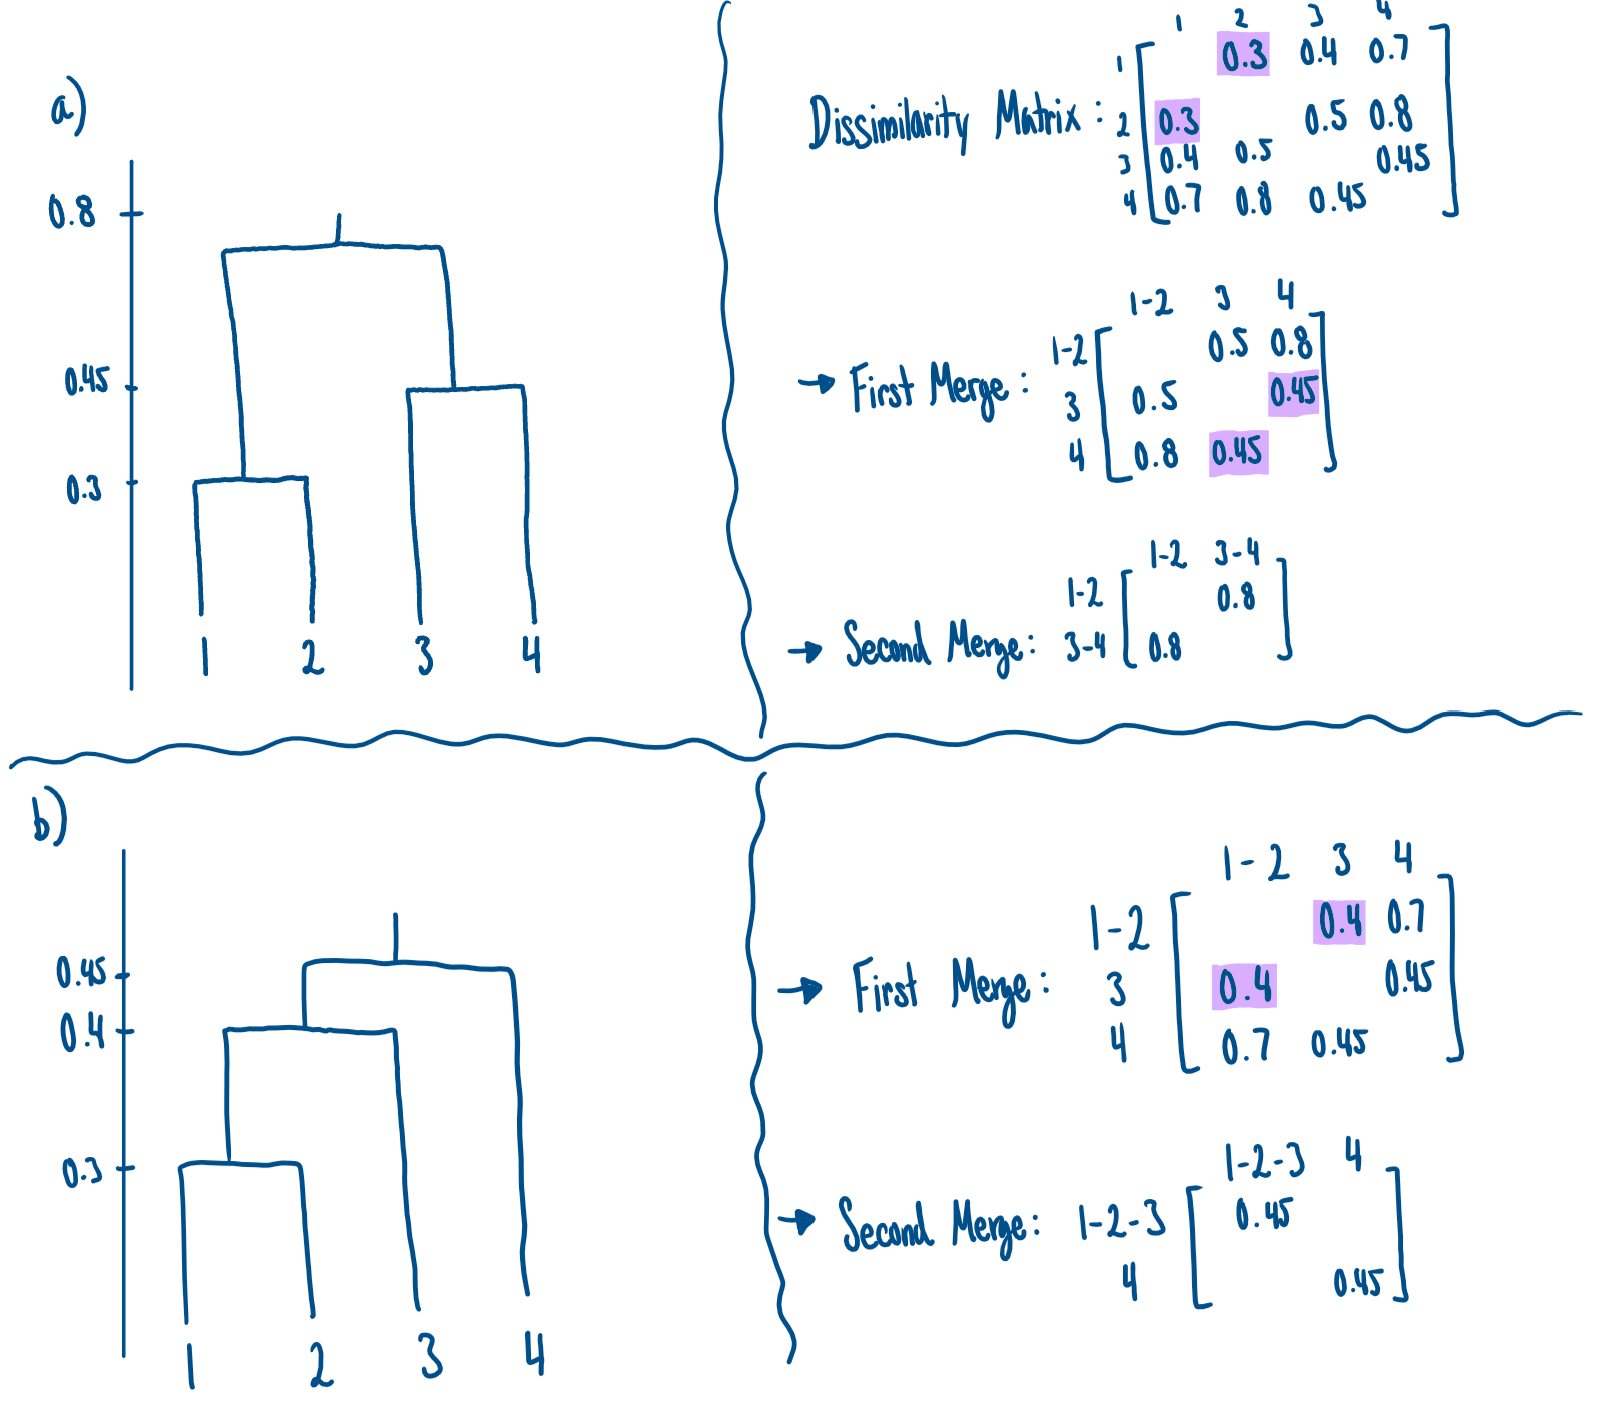
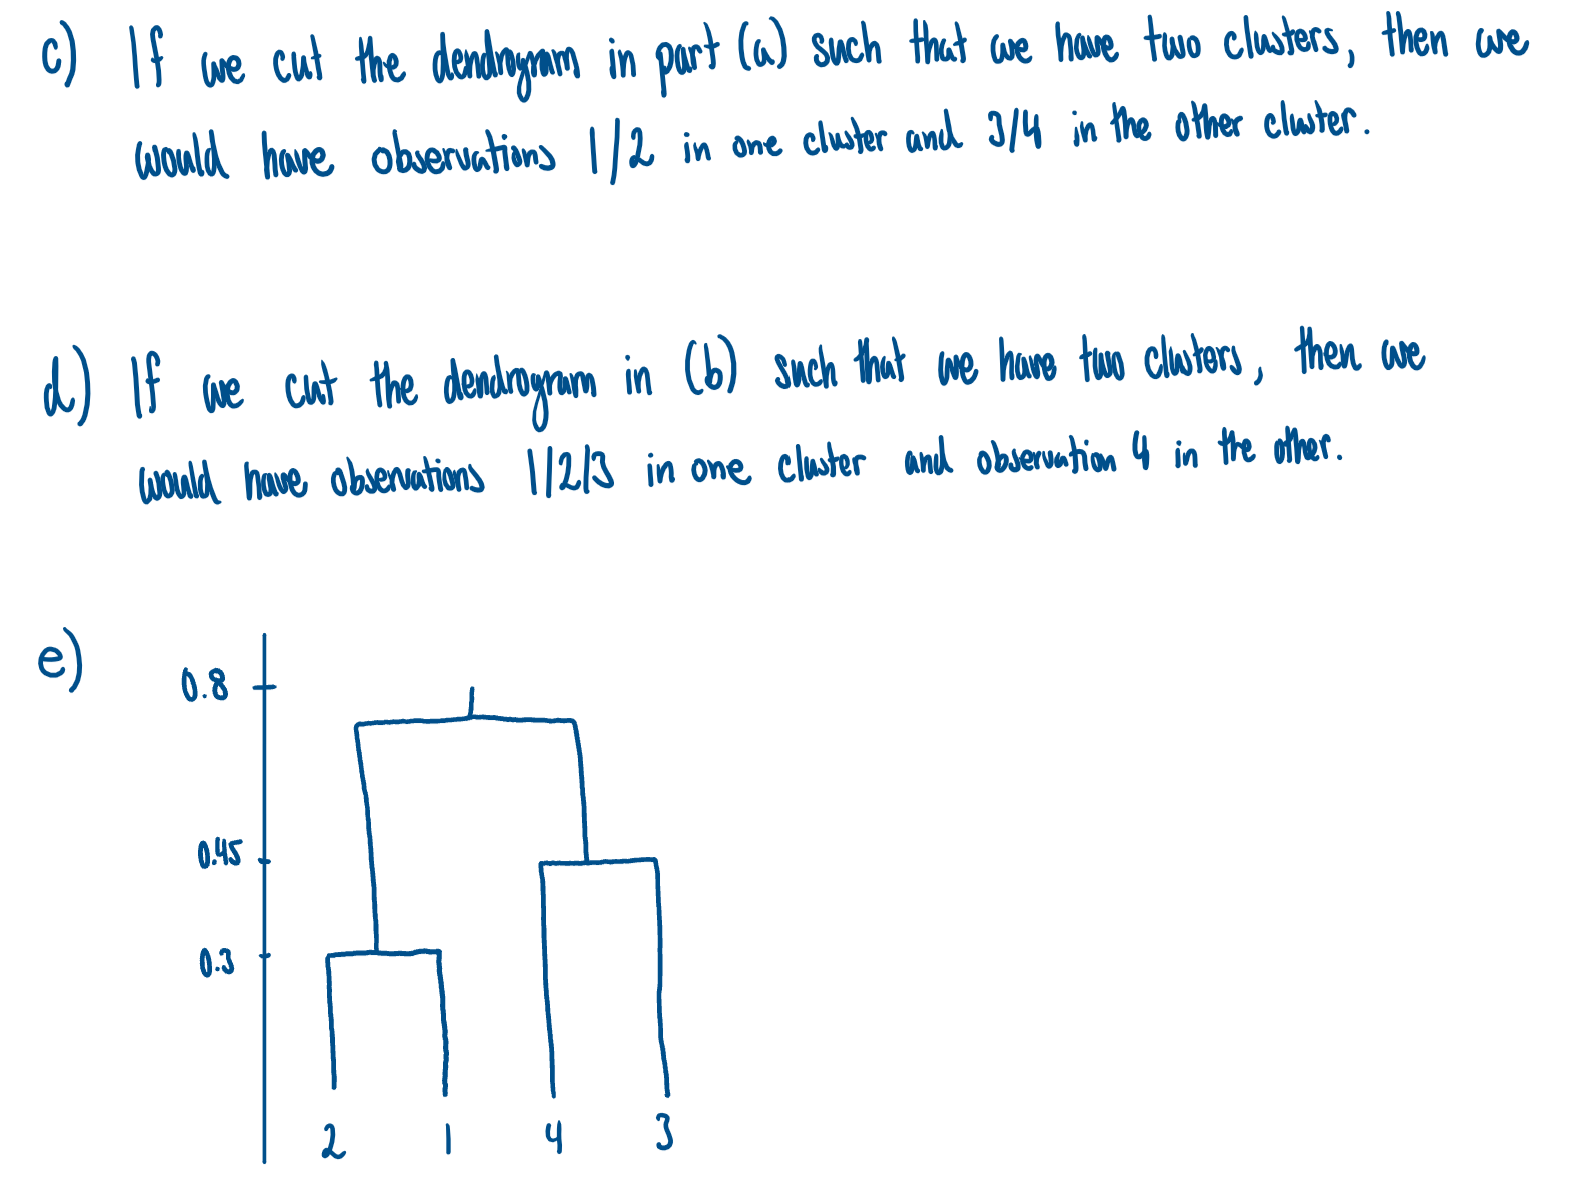